In [1]:
%load_ext autoreload
%autoreload 2

import kinetic_models  # Importa il tuo file

import networkx as nx   #to deal with network
import numpy as np
import sympy as sym
from sympy import *
from sympy.printing.mathml import mathml
init_printing(use_unicode=True) # allow LaTeX printing
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import random 
from collections import Counter

## Parameter Generation


#### Defining Functions

In [17]:
# =============================================================================
# PARAMETER GENERATION
# =============================================================================

def generate_parameter_sets(n_sets: int) -> list[dict]:
    """
    Genera `n_sets` set di parametri rispettando vincoli biologici
    derivati dal principio di proofreading kinetic.

    Parametri:
        k1        : tasso di associazione al sito corretto
        k_1_basal : tasso di dissociazione basale dal sito corretto
        k2        : tasso di associazione al sito errato (≈ k1, ±20%)
        k_2       : tasso di dissociazione dal sito errato (>> k_1_basal)
        alpha     : coefficiente che scala l'effetto del farmaco for the correct binding site 
        beta      : coefficiente che scala l'effetto del farmaco for the incorrect binding site 
        n         : coefficiente di Hill (intero in [1, 5])

    Vincoli (proofreading kinetic):
        1. k1  ≈ k_1_basal  (±20%)
        2. k2  ≈ k1         (±20%)
        3. k_2 ≥ 100 × k_1_basal
    """

    MULTIPLICATION_COSTANT = 100
    param_sets = []
    log_min, log_max = -3, 3

    for _ in range(n_sets):
        k1        = 10 ** np.random.uniform(log_min, log_max)
        k_1_basal = k1 * np.random.uniform(0.8, 1.2)
        k2        = k1 * np.random.uniform(0.8, 1.2)

        min_k_2 = k_1_basal * MULTIPLICATION_COSTANT           
        if min_k_2 > 10 ** log_max:
            k_2 = 10 ** log_max
        else:
            k_2 = 10 ** np.random.uniform(np.log10(min_k_2), log_max)

        alpha = 10 ** np.random.uniform(log_min, log_max)
        beta = 10 ** np.random.uniform(log_min, log_max)
        n     = np.random.randint(1, 6)   # Hill coefficient ≥ 1

        param_sets.append({
            'k1':        round(k1,        6),
            'k_1': round(k_1_basal, 6),
            'k2':        round(k2,        6),
            'k_2':       round(k_2,       6),
            'alpha':     round(alpha,     6),
            'beta':      round(beta,     6),
            'n':         int(n),
        })

    return param_sets

## Model definition:

#### Model 1: Drug effects linearly only BP dissotiation

#### Model 2: Drug effects by hill function the BP dissotiation

#### Model 3: Decoy stabilization ( 1 drug / k )

#### Model 4: Decoy assotiation increase Hill

#### Model 5: Linear effect on BP and Hill function on Decoy

#### Model 6: BP linear 

#### Computing The actual values

In [24]:
# =============================================================================
# Execution and Configuration
# =============================================================================

# Numero di set di parametri sintetici da testare
EPOCHS = 100  # aumentare per stime più robuste, ridurre per test rapidi

# Concentrazioni di farmaco da simulare
DRUG_CONCENTRATIONS = [0, 1, 2, 3, 4]

# Esecuzione
BP_linear = BP_linear_dissociation(
    drug_conc = DRUG_CONCENTRATIONS,
    epochs    = EPOCHS,
)

BP_hill = BP_hill_dissociation(
    drug_conc = DRUG_CONCENTRATIONS,
    epochs    = EPOCHS,
    hill_costant = 0.5              # value choosen by looking at the fitness 
                                    # variation under drug influence,
                                    # K_hill is defined as the value of drug such
                                    # that it reaches half of the
                                    # final concentration of fit 
)

BP_lin_Decoy_hill = BP_linear_Decoy_assotiation_hill(
    drug_conc= DRUG_CONCENTRATIONS,
    epochs= EPOCHS,
    hill_costant= 0.75
)

decoy_stabilization = Decoy_stabilization(
    drug_conc= DRUG_CONCENTRATIONS,
    epochs= EPOCHS,
    hill_costant= 0.75
)

decoy_assotiation = Decoy_assotiation_hill(    drug_conc= DRUG_CONCENTRATIONS,
    epochs= EPOCHS,
    hill_costant= 0.75)

BP_lin_Dec_stabilization = BP_linear_Decoy_stabilization(
        drug_conc= DRUG_CONCENTRATIONS,
    epochs= EPOCHS,
    hill_costant= 0.75
)

result_list = [BP_linear,                           # model 1
               BP_hill,                             # model 2
               decoy_stabilization,                 # model 3
               decoy_assotiation,                   # model 4
               BP_lin_Decoy_hill,                   # model 5
               BP_lin_Dec_stabilization,            # model 6
]

# Store Model numeber for future manipulation
for i in range(len(result_list)):
    for result in result_list[i]:
        result['Model'] = f"Model {i+1}"



#### Filtering parameters by Espected conditions

In [ ]:
# Execute the analysis
successful_sets = filter_parameter_sets_by_trend(result_list)

print(f"Analysis Summary:")
print(f"Total sets analyzed: {sum(len(m) for m in result_list)}")
print(f"Sets matching the required trend: {len(successful_sets)}")


Analysis Summary:
Total sets analyzed: 600
Sets matching the required trend: 390


#### Exploring Results

In [26]:
# =============================================================================
# RESULTS ANALYSIS
# =============================================================================

s = pd.Series([i['origin_model'] for i in successful_sets])

print(f"Relative frequencies of succesfully parameters:\n{s.value_counts(normalize=True) * 100}")

Relative frequencies of succesfully parameters:
Model 1    25.641026
Model 2    25.641026
Model 6    25.384615
Model 5    23.333333
Name: proportion, dtype: float64


In [27]:
# =============================================================================
# GRAPHICAL VISUALIZATION
# =============================================================================


# Some analysy

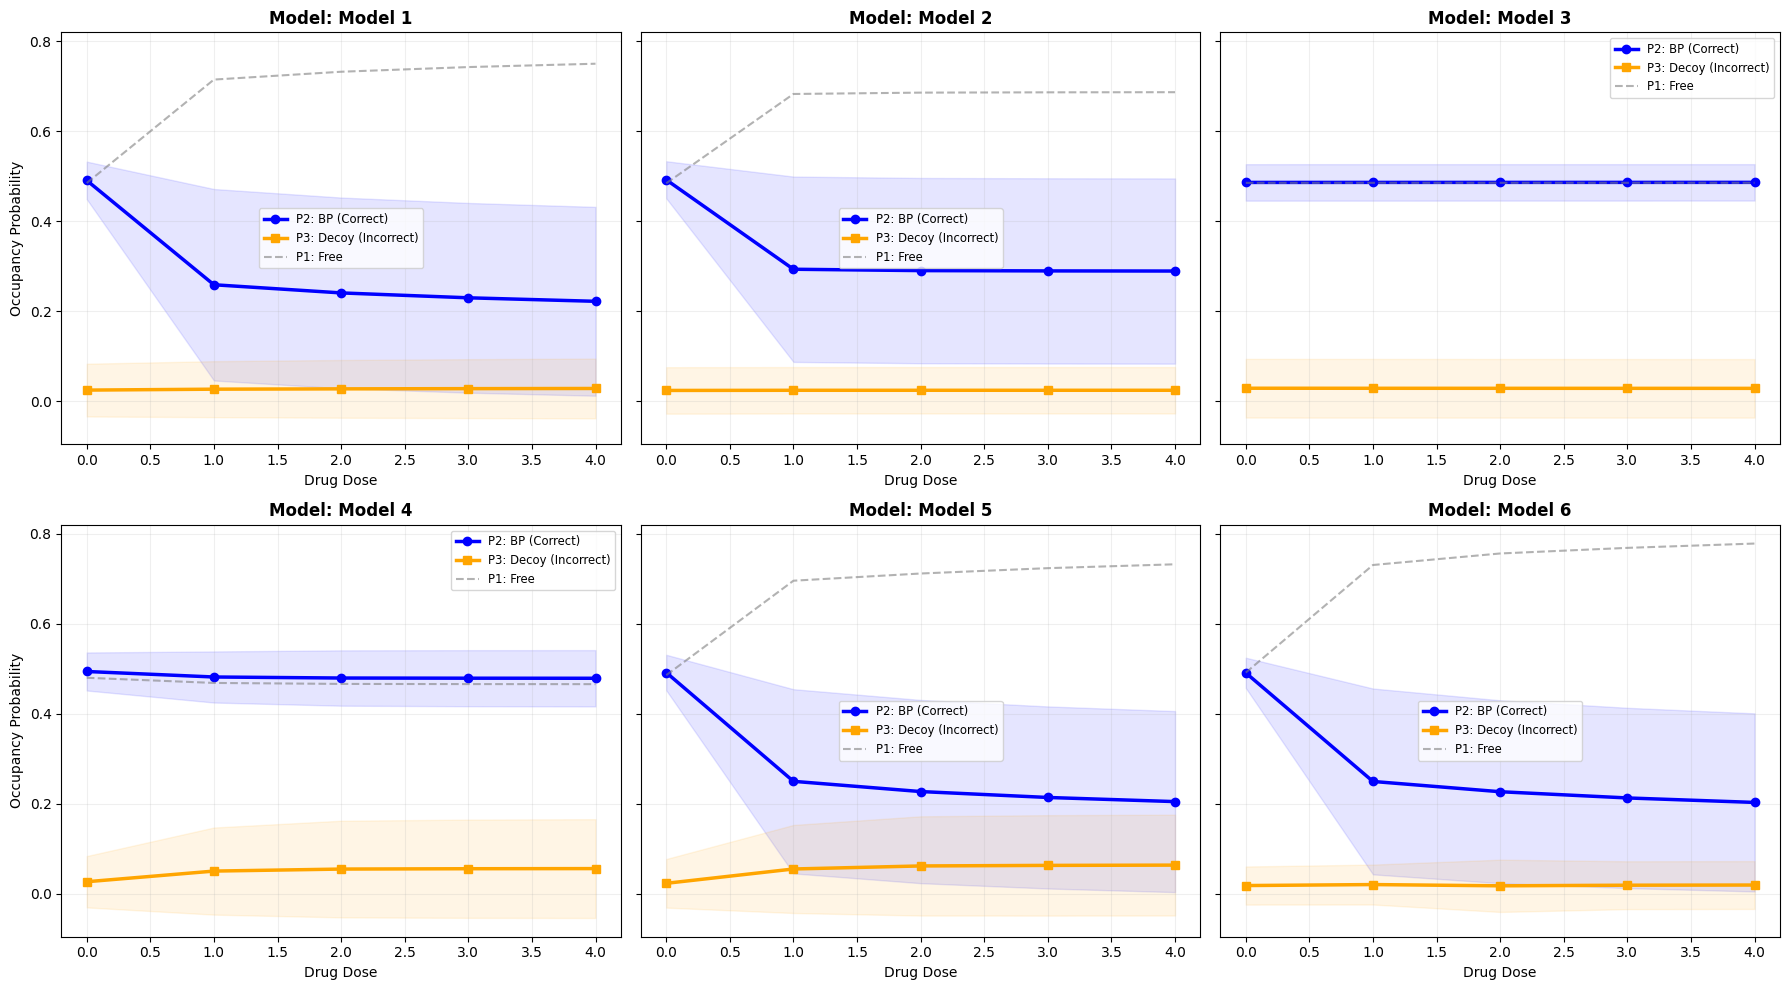

In [28]:
from collections import defaultdict
import math

# 1. Raggruppamento dei dati per Modello e poi per Dose
# Struttura: model_stats[nome_modello][dose] = {P1: [], P2: [], P3: []}
model_stats = defaultdict(lambda: defaultdict(lambda: {'P1': [], 'P2': [], 'P3': []}))

for sublist in result_list:
    for entry in sublist:
        m_name = entry['Model']
        for res in entry['results']:
            d = res['drug']
            model_stats[m_name][d]['P1'].append(res['P1'])
            model_stats[m_name][d]['P2'].append(res['P2'])
            model_stats[m_name][d]['P3'].append(res['P3'])

import math
import numpy as np
import matplotlib.pyplot as plt

# 1. Estrai i nomi dei modelli direttamente dal dizionario creato prima
model_names = sorted(model_stats.keys()) 
num_models = len(model_names)

# 2. Configura la griglia (es. 3 colonne)
cols = 3
rows = math.ceil(num_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows), sharey=True)

# Fondamentale: se axes è un array singolo (1 solo modello), lo rendiamo lista
if num_models == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# 3. Ciclo sui nomi dei modelli
for i, m_name in enumerate(model_names):
    ax = axes[i]
    stats = model_stats[m_name]
    sorted_drugs = sorted(stats.keys())
    
    # Calcolo medie e deviazioni standard
    m_p1 = [np.mean(stats[d]['P1']) for d in sorted_drugs]
    m_p2 = [np.mean(stats[d]['P2']) for d in sorted_drugs]
    m_p3 = [np.mean(stats[d]['P3']) for d in sorted_drugs]
    
    s_p2 = [np.std(stats[d]['P2']) for d in sorted_drugs]
    s_p3 = [np.std(stats[d]['P3']) for d in sorted_drugs]
    
    # Plotting
    ax.plot(sorted_drugs, m_p2, label='P2: BP (Correct)', color='blue', linewidth=2.5, marker='o')
    ax.fill_between(sorted_drugs, np.array(m_p2)-np.array(s_p2), np.array(m_p2)+np.array(s_p2), color='blue', alpha=0.1)
    
    ax.plot(sorted_drugs, m_p3, label='P3: Decoy (Incorrect)', color='orange', linewidth=2.5, marker='s')
    ax.fill_between(sorted_drugs, np.array(m_p3)-np.array(s_p3), np.array(m_p3)+np.array(s_p3), color='orange', alpha=0.1)
    
    ax.plot(sorted_drugs, m_p1, label='P1: Free', color='gray', linestyle='--', alpha=0.6)
    
    ax.set_title(f'Model: {m_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Drug Dose')
    if i % cols == 0:  # Mette il label Y solo sulla prima colonna di ogni riga
        ax.set_ylabel('Occupancy Probability')
    ax.legend(fontsize='small')
    ax.grid(True, alpha=0.2)

# Rimuovi i grafici vuoti se la griglia è più grande dei modelli
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Sensitivity Anlisys
